## Spectral Spreading Models Tutorial
This tutorial demonstrated the complete workflow from continuous spectral models to discretized spectral energy bins:
- **Continuous models** (JONSWAP, Bretschneider, TMA, Donelan, Ochi-Hubble) describe energy distribution as smooth PDFs parameterized by Hs and Tp. Different models have different spectral shapes (peak height, tail behavior), suitable for different ocean regimes
- **Sampling strategies** (uniform, logarithmic, Chebyshev) distribute frequency edges in different ways
- **Sampling domains** (frequency vs. energy) control on which domain the sampling strategy "acts" on
- **DiscreteSpectralSpreading** stores the sampling metadata and provides lazy getters (frequencies, amplitudes, densities, bandwidths) without recomputation


In [1]:
using WaveSpec
using WaveSpec.ContinuousSpectrums
using WaveSpec.SpectralSampling
using WaveSpec.SpectralSpreading
using Plots

# Set a consistent plotting theme
default(fmt=:png, legend=:topright, grid=false)

┌ Info: WaveSpec initialized: Ready for spectral sea state synthesis.
└ @ WaveSpec /home/elmanyer/Documents/TU-Delft/WaveSpec.jl/src/WaveSpec.jl:33


## What is a wave spectrum?
Ocean waves are a superposition of many frequency components, each with its own amplitude and phase. A **spectrum** S(f) describes the energy density distribution across frequencies. Integrating S(f) over all frequencies gives the total variance (proportional to wave height). Realistic spectra are often parameterized by just two key parameters:
- **Hs** (significant wave height [m]): the average height of the highest third of waves
- **Tp** (peak period [s]): the period at which spectral energy is maximum

WaveSpec provides several spectral models, each suitable for different ocean conditions and locations.

## Continuous Spectral Models
WaveSpec implements five built-in spectral models covering a range of ocean conditions. Each is a continuous PDF parameterized by Hs and Tp (and sometimes additional shape parameters).

In [2]:
# Define target parameters
Hs_target = 3.0      # Significant wave height [m]
Tp_target = 10.0     # Peak period [s]

# Build different continuous spectrum models
# Each is a function of (Hs, Tp) with optional shape parameters

# 1. JONSWAP: most common for Atlantic/North Sea
# Shape parameter γ controls peakedness (γ=1 is flat, γ≈3.3 is typical)
spec_jonswap = JONSWAP(Hs_target, Tp_target)

# 2. Bretschneider: swell-dominated conditions
spec_bretschneider = Bretschneider(Hs_target, Tp_target)

# 3. TMA (Texel-Marsen-Arsloe): shallow water (depth-dependent)
h_water = 30.0       # Water depth [m]
spec_tma = TMA(Hs_target, Tp_target, h_water)

# 4. Donelan: wind-sea conditions
U10 = 12.0          # Wind speed at 10 m height [m/s]
spec_donelan = Donelan(Hs_target, Tp_target, U10)

# 5. Ochi-Hubble: bimodal (two swell systems)
# Requires two swell partitions with separate Hs, Tp, and weights
Hs_1, Tp_1 = 2.0, 10.0  # First swell
Hs_2, Tp_2 = 1.0, 5.0   # Second swell
λ1, λ2 = 2.0, 1.0       # Partition weights
spec_ochihubble = OchiHubble(Hs_1, Tp_1, λ1, Hs_2, Tp_2, λ2)

# Extract model info
println("Hs (JONSWAP):      ", round(ContinuousSpectrums.get_Hs(spec_jonswap), digits=3), " m")
println("Tp (JONSWAP):      ", round(ContinuousSpectrums.get_Tp(spec_jonswap), digits=3), " s")
println("fp (peak freq):    ", round(1.0/ContinuousSpectrums.get_Tp(spec_jonswap), digits=3), " Hz")

Hs (JONSWAP):      3.0 m
Tp (JONSWAP):      10.0 s
fp (peak freq):    0.1 Hz


### Compare spectral models visually
Plot the spectral density S(f) for each model over the same frequency range. This shows how they differ in peak height, bandwidth, and tail behavior.

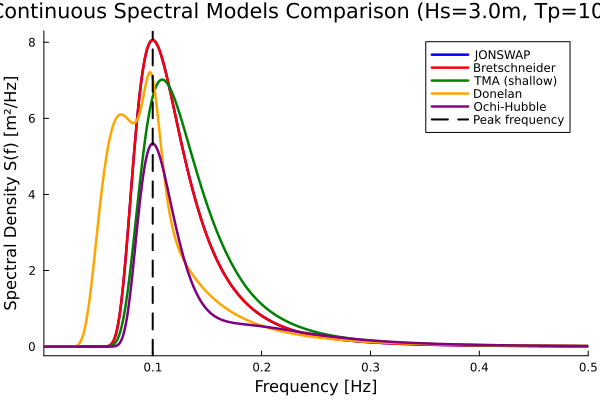

In [3]:
# Evaluate all models at a fine frequency grid
fmin = ContinuousSpectrums.get_fmin(spec_jonswap)           # Minimum recommended frequency
fmax = ContinuousSpectrums.get_fmax(spec_jonswap)           # Maximum recommended frequency
f_range = range(fmin, fmax, length=500)

# Compute spectral densities for all models
S_jonswap = [ContinuousSpectrums.get_density(spec_jonswap, f) for f in f_range]
S_bretschneider = [ContinuousSpectrums.get_density(spec_bretschneider, f) for f in f_range]
S_tma = [ContinuousSpectrums.get_density(spec_tma, f) for f in f_range]
S_donelan = [ContinuousSpectrums.get_density(spec_donelan, f) for f in f_range]
S_ochihubble = [ContinuousSpectrums.get_density(spec_ochihubble, f) for f in f_range]

# Plot all models for comparison
p_models = plot(f_range, S_jonswap, label="JONSWAP", lw=2.5, color=:blue)
plot!(p_models, f_range, S_bretschneider, label="Bretschneider", lw=2.5, color=:red)
plot!(p_models, f_range, S_tma, label="TMA (shallow)", lw=2.5, color=:green)
plot!(p_models, f_range, S_donelan, label="Donelan", lw=2.5, color=:orange)
plot!(p_models, f_range, S_ochihubble, label="Ochi-Hubble", lw=2.5, color=:purple)

xlabel!(p_models, "Frequency [Hz]")
ylabel!(p_models, "Spectral Density S(f) [m²/Hz]")
title!(p_models, "Continuous Spectral Models Comparison (Hs=$(Hs_target)m, Tp=$(Tp_target)s)")
xlims!(p_models, fmin, fmax)

# Mark the peak frequency
fp = 1.0 / ContinuousSpectrums.get_Tp(spec_jonswap)
vline!(p_models, [fp], label="Peak frequency", lw=2, color=:black, linestyle=:dash)

p_models

## From Continuous to Discrete: The DiscreteSpectralSpreading Structure
A discrete spectrum samples the continuous model at a finite set of frequencies, creating energy bins. From a predefined continuous spectral model describing the frequencial energy distribution in a sea, the discretization can be obtained by selecting 3 key features:
- **Sampling domain**: which domain to sample according to the sampling strategy (frequency or energy). By default, this is set to **FrequencyDomain**.
- **Sampling strategy**: how samples are distributed (uniform, logarithmic, Chebyshev) in the selected domain
- **Number of bins**: nf samples creates nf-1 bins

### Sampling Strategies
- **UniformSampling**: equally spaced in the chosen domain
- **LogSampling**: logarithmically spaced (good for wide frequency ranges)
- **ChebyshevSampling**: Chebyshev nodes (minimizes interpolation error)

### Sampling Domains
- **FrequencyDomain**: force sampling strategy distribution on the frequency domain
- **EnergyDomain**: force sampling strategy distribution on the energy domain

In [4]:
# Create discrete spectra with different strategies
# All use the JONSWAP model as the base
nf = 60                    # Number of frequency bins (nf-1 bands)
fmin = get_fmin(spec_jonswap)
fmax = get_fmax(spec_jonswap)

# 1. Uniform sampling in frequency domain (equal Δf)
ds_uniform_freq = DiscreteSpectralSpreading(spec_jonswap, UniformSampling(), 
                                             fmin, fmax, nf; 
                                             domain=FrequencyDomain(), mess=false)

# 2. Uniform sampling in energy domain (equal energy per bin, unequal Δf)
ds_uniform_energy = DiscreteSpectralSpreading(spec_jonswap, UniformSampling(), 
                                               fmin, fmax, nf; 
                                               domain=EnergyDomain(), mess=false)

# 3. Logarithmic sampling in frequency domain
ds_log = DiscreteSpectralSpreading(spec_jonswap, LogSampling(), 
                                    fmin, fmax, nf; 
                                    domain=FrequencyDomain(), mess=false)

println("Discrete spectra created with three strategies.")

Discrete spectra created with three strategies.


### Extract discrete spectrum information
Once a `DiscreteSpectralSpreading` is built, we can query its properties:

In [5]:
# Get all properties from the uniform-frequency discrete spectrum
freqs = SpectralSpreading.get_frequencies(ds_uniform_freq)              # Frequency edges [Hz]
central_freqs = SpectralSpreading.get_central_frequencies(ds_uniform_freq)  # Bin centers
bandwidths = SpectralSpreading.get_bandwidths(ds_uniform_freq)         # Δf for each bin
densities = SpectralSpreading.get_densities(ds_uniform_freq)           # S(f) at bin centers
amplitudes = SpectralSpreading.get_amplitudes(ds_uniform_freq)         # Wave amplitudes A_i

println("\n=== Discrete Spectrum Properties ===")
println("Number of edges (nf):   ", length(freqs))
println("Number of bins (nf-1):  ", length(central_freqs))
println("\nFirst 5 frequency edges: ")
println(freqs[1:5])
println("\nFirst 5 bin centers:")
println(central_freqs[1:5])
println("\nFirst 5 bandwidths Δf:")
println(bandwidths[1:5])
println("\nFirst 5 spectral densities S(f):")
println(round.(densities[1:5], digits=4))
println("\nFirst 5 amplitudes A_i (wave component amplitudes):")
println(round.(amplitudes[1:5], digits=4))


=== Discrete Spectrum Properties ===
Number of edges (nf):   60
Number of bins (nf-1):  59

First 5 frequency edges: 
[1.0e-5, 0.008484406779661016, 0.016958813559322033, 0.02543322033898305, 0.03390762711864407]

First 5 bin centers:
[0.004247203389830508, 0.012721610169491524, 0.02119601694915254, 0.02967042372881356, 0.03814483050847457]

First 5 bandwidths Δf:
[0.008474406779661017, 0.008474406779661017, 0.008474406779661017, 0.00847440677966102, 0.008474406779661013]

First 5 spectral densities S(f):
[0.0, 0.0, 0.0, 0.0, 0.0]

First 5 amplitudes A_i (wave component amplitudes):
[0.0, 0.0, 0.0, 0.0, 0.0]


### Visualize discretization strategies
Compare how different sampling strategies distribute bin centers and widths.

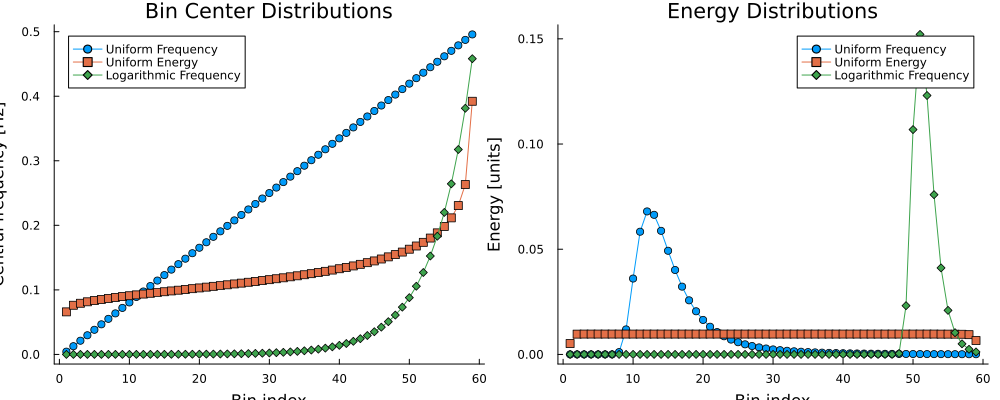

In [ ]:
# Collect data from all three strategies
cf_uniform_freq = SpectralSpreading.get_central_frequencies(ds_uniform_freq)
cf_uniform_energy = SpectralSpreading.get_central_frequencies(ds_uniform_energy)
cf_log = SpectralSpreading.get_central_frequencies(ds_log)

E_uniform_freq = SpectralSpreading.get_energies(ds_uniform_freq)
E_uniform_energy = SpectralSpreading.get_energies(ds_uniform_energy)
E_log = SpectralSpreading.get_energies(ds_log)

# Plot bin center distributions
p_cf = plot(cf_uniform_freq, label="Uniform Frequency", marker=:circle, markersize=4, legend=:topleft)
plot!(p_cf, cf_uniform_energy, label="Uniform Energy", marker=:square, markersize=4)
plot!(p_cf, cf_log, label="Logarithmic Frequency", marker=:diamond, markersize=4)
xlabel!(p_cf, "Bin index")
ylabel!(p_cf, "Central frequency [Hz]")
title!(p_cf, "Bin Center Distributions")

# Plot energy distributions
p_bw = plot(E_uniform_freq, label="Uniform Frequency", marker=:circle, markersize=4, legend=:topright)
plot!(p_bw, E_uniform_energy, label="Uniform Energy", marker=:square, markersize=4)
plot!(p_bw, E_log, label="Logarithmic Frequency", marker=:diamond, markersize=4)
xlabel!(p_bw, "Bin index")
ylabel!(p_bw, "Energy [units]")
title!(p_bw, "Energy Distributions")

plot(p_cf, p_bw, layout=(1,2), size=(1000, 400))

### Compare strategies: energy conservation
A key test: the sum of energies in discrete bins should match the target Hs. Compute the reconstructed Hs from each discretization.

In [7]:
# Extract amplitudes from all discretization strategies
amp_uniform_freq = SpectralSpreading.get_amplitudes(ds_uniform_freq)
amp_uniform_energy = SpectralSpreading.get_amplitudes(ds_uniform_energy)
amp_log = SpectralSpreading.get_amplitudes(ds_log)

# Compute moments (m_0 = variance, relates to Hs)
# m_0 = Σ A_i^2 / 2

m0_uniform_freq = sum((amp_uniform_freq).^2 ./ 2.0)
m0_uniform_energy = sum((amp_uniform_energy).^2 ./ 2.0)
m0_log = sum((amp_log).^2 ./ 2.0)

Hs_reconstructed_freq = 4.0 * sqrt(m0_uniform_freq)
Hs_reconstructed_energy = 4.0 * sqrt(m0_uniform_energy)
Hs_reconstructed_log = 4.0 * sqrt(m0_log)

Hs_target_val = ContinuousSpectrums.get_Hs(spec_jonswap)

println("\n=== Energy Conservation Test ===")
println("Target Hs:                 ", round(Hs_target_val, digits=3), " m")
println("Reconstructed Hs (Freq):   ", round(Hs_reconstructed_freq, digits=3), " m")
println("Reconstructed Hs (Energy): ", round(Hs_reconstructed_energy, digits=3), " m")
println("Reconstructed Hs (Log):    ", round(Hs_reconstructed_log, digits=3), " m")
println("\nError (Freq):   ", round((Hs_reconstructed_freq - Hs_target_val) / Hs_target_val * 100, digits=2), "%")
println("Error (Energy): ", round((Hs_reconstructed_energy - Hs_target_val) / Hs_target_val * 100, digits=2), "%")
println("Error (Log):    ", round((Hs_reconstructed_log - Hs_target_val) / Hs_target_val * 100, digits=2), "%")


=== Energy Conservation Test ===
Target Hs:                 3.0 m
Reconstructed Hs (Freq):   3.0 m
Reconstructed Hs (Energy): 3.0 m
Reconstructed Hs (Log):    3.0 m

Error (Freq):   0.0%
Error (Energy): -0.0%
Error (Log):    0.0%


## Spectral Moments and Characteristic Parameters
From the discrete spectrum, we can compute spectral moments and derived parameters. The zeroth moment m₀ relates to total energy (variance). The first moment m₁ relates to mean frequency.

In [8]:
# m_n = Σ (f_i)^n * S(f_i) * Δf

bandwidths_freq = SpectralSpreading.get_bandwidths(ds_uniform_freq)
densities_freq = SpectralSpreading.get_densities(ds_uniform_freq)

m0 = sum(densities_freq .* bandwidths_freq)       # Zeroth moment (variance proxy)
m1 = sum(central_freqs .* densities_freq .* bandwidths_freq)   # First moment
m2 = sum((central_freqs.^2) .* densities_freq .* bandwidths_freq)   # Second moment

# Derived parameters
Hs_from_m0 = 4.0 * sqrt(m0)
mean_freq = m1 / m0
spectral_width = sqrt(1.0 - m1^2 / (m0 * m2))   # Spectral narrowness

println("\n=== Spectral Moments ===")
println("m₀ (variance):          ", round(m0, digits=4))
println("m₁ (first moment):      ", round(m1, digits=4))
println("m₂ (second moment):     ", round(m2, digits=4))
println("\nDerived Parameters:")
println("Hs (from m₀):           ", round(Hs_from_m0, digits=3), " m")
println("Mean frequency:         ", round(mean_freq, digits=4), " Hz")
println("Spectral width param:   ", round(spectral_width, digits=4))


=== Spectral Moments ===
m₀ (variance):          0.5625
m₁ (first moment):      0.0723
m₂ (second moment):     0.0106

Derived Parameters:
Hs (from m₀):           3.0 m
Mean frequency:         0.1285 Hz
Spectral width param:   0.3526
